In [ ]:
# PROJECT TITLE:
# Crop Yield Prediction Using Linear Regression
#
# PROJECT OBJECTIVE:
# The objective of this project is to build a Linear Regression model that
# predicts agricultural crop yield (hg/ha_yield) based on historical climate,
# agricultural input, and temporal data.
#
# Specifically, we aim to:
# 1. Load and clean agricultural yield data
# 2. Perform exploratory preprocessing and feature engineering
# 3. Prepare numerical and categorical variables for modeling
# 4. Train a Linear Regression model with regularization
# 5. Perform cross-validation and hyperparameter tuning
# 6. Evaluate model performance using regression metrics
# 7. Handle data imbalance / skew in the target variable
#
# TARGET VARIABLE:
# - hg/ha_yield (continuous numerical variable)
#
# FEATURES:
# - Year
# - average_rain_fall_mm_per_year
# - pesticides_tonnes
# - avg_temp
# - Area (categorical)
# - Item (categorical)

# Library imports

# Core numerical and data manipulation libraries
import numpy as np                      # Numerical operations
import pandas as pd                     # Data loading and manipulation

# Data visualization libraries (optional but useful)
import matplotlib.pyplot as plt         # Plotting
import seaborn as sns                   # Statistical plots

# Scikit-learn preprocessing utilities
from sklearn.model_selection import train_test_split  # Data splitting
from sklearn.preprocessing import StandardScaler      # Feature scaling
from sklearn.preprocessing import OneHotEncoder       # Encode categorical data
from sklearn.compose import ColumnTransformer          # Apply different transforms
from sklearn.pipeline import Pipeline                  # ML pipelines

# Regression models
from sklearn.linear_model import LinearRegression      # Ordinary Least Squares
from sklearn.linear_model import Ridge                 # L2 regularization
from sklearn.linear_model import Lasso                 # L1 regularization
from sklearn.linear_model import ElasticNet             # L1 + L2 regularization

# Model evaluation metrics
from sklearn.metrics import mean_absolute_error        # MAE
from sklearn.metrics import mean_squared_error         # MSE
from sklearn.metrics import r2_score                   # R² score

# Cross-validation and hyperparameter tuning
from sklearn.model_selection import GridSearchCV       # Grid search CV
from sklearn.model_selection import KFold              # K-Fold cross validation





In [ ]:
# 2. LOAD THE DATA


# Load CSV file into a pandas DataFrame
df = pd.read_csv("YIELD.csv")

# Display the first few rows to understand the structure
print(df.head())



# 3. BASIC DATA INSPECTION


# Check dataset shape (rows, columns)
print("Dataset shape:", df.shape)

# Check column names and data types
print(df.info())

# Summary statistics for numerical columns
print(df.describe())



# 4. DATA CLEANING


# Check for missing values in each column
print(df.isnull().sum())

# Strategy:
# - Numerical columns: fill missing values with median
# - Categorical columns: fill missing values with mode

# Fill missing numerical values
numerical_cols = [
    "Year",
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values
categorical_cols = ["Area", "Item"]

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)




   ID     Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0   0  Albania        Maize  1990        36613                           1485   
1   1  Albania     Potatoes  1990        66667                           1485   
2   2  Albania  Rice, paddy  1990        23333                           1485   
3   3  Albania      Sorghum  1990        12500                           1485   
4   4  Albania     Soybeans  1990         7000                           1485   

   pesticides_tonnes  avg_temp  
0              121.0     16.37  
1              121.0     16.37  
2              121.0     16.37  
3              121.0     16.37  
4              121.0     16.37  
Dataset shape: (28242, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             28242 non-null  int64  
 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_50948\1077293663.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_50948\1077293663.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

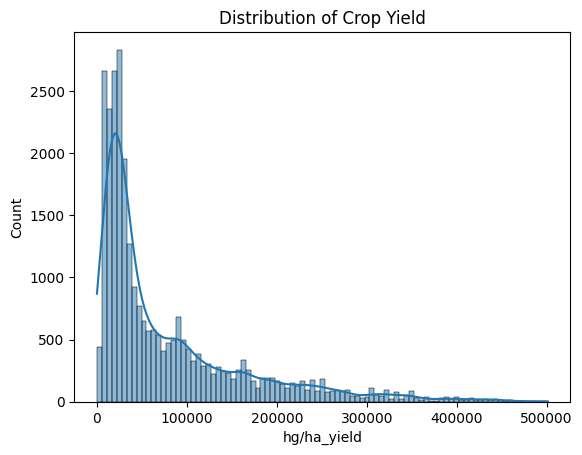

In [ ]:
# 5. TARGET VARIABLE ANALYSIS (IMBALANCE / SKEW)


# Plot distribution of target variable
sns.histplot(df["hg/ha_yield"], kde=True)
plt.title("Distribution of Crop Yield")
plt.show()

# Explanation:
# Regression does not suffer from class imbalance like classification,
# but skewed target distributions can hurt model performance.
# If the target is heavily right-skewed, we can apply log transformation.

# Apply log transformation if needed
df["hg_ha_yield_log"] = np.log1p(df["hg/ha_yield"])

# Use transformed target for modeling
target = "hg_ha_yield_log"



# 6. FEATURE / TARGET SEPARATION


# Define input features (X) and target variable (y)
X = df.drop(columns=["hg/ha_yield", "hg_ha_yield_log", "ID"])
y = df[target]



# 7. TRAIN-TEST SPLIT (TIME-AWARE)


# Sort data by year to avoid data leakage
df_sorted = df.sort_values("Year")

X = df_sorted.drop(columns=["hg/ha_yield", "hg_ha_yield_log", "ID"])
y = df_sorted[target]

# Use earlier years for training and later years for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)





In [ ]:
# 8. PREPROCESSING PIPELINE


# Separate numerical and categorical columns
num_features = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

cat_features = ["Area", "Item"]

# Numerical preprocessing:
# - StandardScaler ensures features have mean=0 and std=1
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# - OneHotEncoder converts categories into binary columns
cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)



# 9. BASELINE LINEAR REGRESSION MODEL


# Create pipeline with preprocessing + model
linreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model
linreg_pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = linreg_pipeline.predict(X_test)





In [ ]:
# 10. MODEL EVALUATION


# Compute regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Baseline Linear Regression Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)





Baseline Linear Regression Performance:
MAE: 0.362584546683424
RMSE: 0.47910666514364514
R² Score: 0.8115051714339377


In [ ]:
# 11. REGULARIZATION (RIDGE, LASSO, ELASTIC NET)


# Ridge Regression (L2)
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

# Lasso Regression (L1)
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=5000))
])

# ElasticNet Regression (L1 + L2)
elastic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=5000))
])


# 12. HYPERPARAMETER TUNING WITH CROSS-VALIDATION


# Define hyperparameter grid
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 50]
}

# K-Fold cross-validation
cv = KFold(n_splits=5, shuffle=False)

# GridSearch for Ridge Regression
grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# Fit grid search
grid_ridge.fit(X_train, y_train)

print("Best Ridge alpha:", grid_ridge.best_params_)
print("Best CV R²:", grid_ridge.best_score_)



# 13. FINAL MODEL EVALUATION


# Use best model from grid search
best_model = grid_ridge.best_estimator_

# Predict on test set
y_test_pred = best_model.predict(X_test)

# Final evaluation metrics
final_mae = mean_absolute_error(y_test, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
final_r2 = r2_score(y_test, y_test_pred)

print("\nFinal Tuned Model Performance:")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R² Score:", final_r2)



# RF & SVM


Best Ridge alpha: {'model__alpha': 0.1}
Best CV R²: 0.835797181472202

Final Tuned Model Performance:
MAE: 0.36255435462355257
RMSE: 0.4790976167157325
R² Score: 0.811512291208662
